# Task 04 - Regression Model for Project Budget Prediction

Name: Malaika Noor

Objective:
Predict project budget using client dataset and compare Linear Regression with Ridge Regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Creating Sample Dataset

In [2]:
data = {
    "Clients":[10,15,20,25,30,35,40,45,50,55],
    "Team_Size":[2,3,4,5,6,7,8,9,10,11],
    "Duration_Months":[1,2,3,4,5,6,7,8,9,10],
    "Project_Budget":[5000,8000,12000,15000,18000,22000,26000,30000,35000,40000]
}

df = pd.DataFrame(data)

print(df)

   Clients  Team_Size  Duration_Months  Project_Budget
0       10          2                1            5000
1       15          3                2            8000
2       20          4                3           12000
3       25          5                4           15000
4       30          6                5           18000
5       35          7                6           22000
6       40          8                7           26000
7       45          9                8           30000
8       50         10                9           35000
9       55         11               10           40000


## Feature Selection



In [3]:
X = df[["Clients","Team_Size","Duration_Months"]]

y = df["Project_Budget"]

print(X.head())

   Clients  Team_Size  Duration_Months
0       10          2                1
1       15          3                2
2       20          4                3
3       25          5                4
4       30          6                5


## Train Test Split (80/20)


   Client_ID     Name       City   Age   Salary Subscription
0          1      Ali    Karachi  22.0  50000.0        Basic
1          2     Sara     Lahore  25.0  60000.0      Premium
2          3    Ahmed    Karachi  26.6  55000.0        Basic
3          4   Ayesha  Islamabad  28.0  70000.0      Premium
4          4   Ayesha  Islamabad  28.0  70000.0      Premium
5          5  Unknown     Lahore  30.0  61000.0        Basic


## Removing Duplicate Records

In [ ]:
print("Rows Before Removing Duplicates:", len(df))

df = df.drop_duplicates()

print("Rows After Removing Duplicates:", len(df))
print(df)

Rows Before Removing Duplicates: 6
Rows After Removing Duplicates: 5
   Client_ID     Name       City   Age   Salary Subscription
0          1      Ali    Karachi  22.0  50000.0        Basic
1          2     Sara     Lahore  25.0  60000.0      Premium
2          3    Ahmed    Karachi  26.6  55000.0        Basic
3          4   Ayesha  Islamabad  28.0  70000.0      Premium
5          5  Unknown     Lahore  30.0  61000.0        Basic


## Label Encoding

In [ ]:
le = LabelEncoder()

df["Subscription"] = le.fit_transform(df["Subscription"])

print(df)

   Client_ID     Name       City   Age   Salary  Subscription
0          1      Ali    Karachi  22.0  50000.0             0
1          2     Sara     Lahore  25.0  60000.0             1
2          3    Ahmed    Karachi  26.6  55000.0             0
3          4   Ayesha  Islamabad  28.0  70000.0             1
5          5  Unknown     Lahore  30.0  61000.0             0


## One Hot Encoding

In [ ]:
df = pd.get_dummies(df, columns=["City"])

print(df)

   Client_ID     Name   Age   Salary  Subscription  City_Islamabad  \
0          1      Ali  22.0  50000.0             0           False   
1          2     Sara  25.0  60000.0             1           False   
2          3    Ahmed  26.6  55000.0             0           False   
3          4   Ayesha  28.0  70000.0             1            True   
5          5  Unknown  30.0  61000.0             0           False   

   City_Karachi  City_Lahore  
0          True        False  
1         False         True  
2          True        False  
3         False        False  
5         False         True  


## Before Scaling

In [ ]:
print(df[["Age","Salary"]])

    Age   Salary
0  22.0  50000.0
1  25.0  60000.0
2  26.6  55000.0
3  28.0  70000.0
5  30.0  61000.0


## Feature Scaling Using MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

df[["Age","Salary"]] = scaler.fit_transform(df[["Age","Salary"]])

print(df[["Age","Salary"]])

     Age  Salary
0  0.000    0.00
1  0.375    0.50
2  0.575    0.25
3  0.750    1.00
5  1.000    0.55


## Linear Regression Model

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)


## Ridge Evaluation

In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Ridge Predictions:
[34327.69623484  7672.30376516]


## Ridge Regression

In [14]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("\nRidge Regression Results")
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("MSE:", mean_squared_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2 Score:", r2_score(y_test, ridge_pred))


Ridge Regression Results
MAE: 499.9999999999991
MSE: 279688.587487054
RMSE: 528.8559231842393
R2 Score: 0.9984653575446526


## Actual vs Predicted Plot

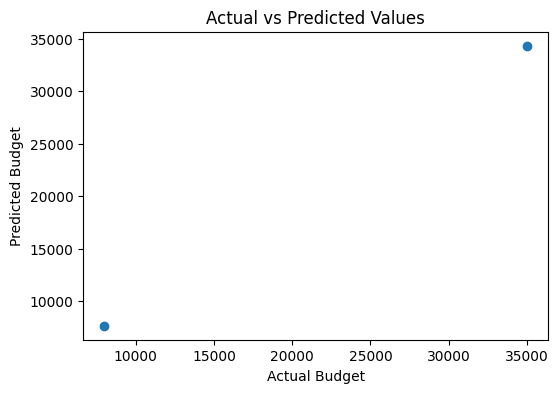

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Budget")
plt.ylabel("Predicted Budget")
plt.title("Actual vs Predicted Values")
plt.show()

## Performance Analysis

The Linear Regression and Ridge Regression models were trained to predict project budget.

Both models produced good predictions with a high R2 Score and low error values.

Linear Regression performed slightly better because the sample dataset has a simple linear relationship between features and project budget.

Overall, the model can effectively estimate project budgets based on client count, team size, and project duration.